# CNN from Scratch — Fashion MNIST

> **UE24CS645BC2 | Deep Learning Theory & Practice | Assignment 1**

A Convolutional Neural Network built **entirely from first principles** using only NumPy.  
No PyTorch, no TensorFlow, no Keras — every layer and every gradient is handwritten.

---

### Architecture
```
Input  (N, 1, 28, 28)
  │
  ▼  ConvLayer(1→8, 3×3, pad=1)  + ReLU  →  (N,  8, 28, 28)
  ▼  MaxPool(2×2)                          →  (N,  8, 14, 14)
  ▼  ConvLayer(8→16, 3×3, pad=1) + ReLU  →  (N, 16, 14, 14)
  ▼  MaxPool(2×2)                          →  (N, 16,  7,  7)
  ▼  Flatten                              →  (N, 784)
  ▼  FC(784 → 128, ReLU)                  →  (N, 128)
  ▼  FC(128 → 10,  Softmax)               →  (N,  10)
```

## 0. Imports

In [1]:
import numpy as np
import struct
import os
import urllib.request
import gzip
import shutil
import time
import matplotlib.pyplot as plt

np.random.seed(42)
print("NumPy version:", np.__version__)

NumPy version: 2.3.5


---
## 1. Dataset — Fashion MNIST

Fashion MNIST contains **70,000 grayscale 28×28 images** across 10 clothing categories.

| ID | Label |
|----|-------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

In [2]:
FASHION_MNIST_URLS = {
    "train_images": "https://storage.googleapis.com/tensorflow/tf-keras-datasets/train-images-idx3-ubyte.gz",
    "train_labels": "https://storage.googleapis.com/tensorflow/tf-keras-datasets/train-labels-idx1-ubyte.gz",
    "test_images":  "https://storage.googleapis.com/tensorflow/tf-keras-datasets/t10k-images-idx3-ubyte.gz",
    "test_labels":  "https://storage.googleapis.com/tensorflow/tf-keras-datasets/t10k-labels-idx1-ubyte.gz",
}

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


def download_and_load_fashion_mnist(data_dir="./fashion_mnist_data"):
    """Download Fashion MNIST if not present and return numpy arrays."""
    os.makedirs(data_dir, exist_ok=True)

    def _download(url, dest):
        gz_path = dest + ".gz"
        if not os.path.exists(dest):
            print(f"  Downloading {os.path.basename(dest)} ...")
            urllib.request.urlretrieve(url, gz_path)
            with gzip.open(gz_path, "rb") as f_in, open(dest, "wb") as f_out:
                shutil.copyfileobj(f_in, f_out)
            os.remove(gz_path)

    def _read_images(path):
        with open(path, "rb") as f:
            magic, n, rows, cols = struct.unpack(">IIII", f.read(16))
            return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows, cols)

    def _read_labels(path):
        with open(path, "rb") as f:
            magic, n = struct.unpack(">II", f.read(8))
            return np.frombuffer(f.read(), dtype=np.uint8)

    paths = {
        "train_images": os.path.join(data_dir, "train-images-idx3-ubyte"),
        "train_labels": os.path.join(data_dir, "train-labels-idx1-ubyte"),
        "test_images":  os.path.join(data_dir, "t10k-images-idx3-ubyte"),
        "test_labels":  os.path.join(data_dir, "t10k-labels-idx1-ubyte"),
    }

    for key, url in FASHION_MNIST_URLS.items():
        _download(url, paths[key])

    X_train = _read_images(paths["train_images"]).astype(np.float32) / 255.0
    y_train = _read_labels(paths["train_labels"])
    X_test  = _read_images(paths["test_images"]).astype(np.float32) / 255.0
    y_test  = _read_labels(paths["test_labels"])

    # Shape: (N, 1, H, W) – channel-first
    X_train = X_train[:, np.newaxis, :, :]
    X_test  = X_test[:, np.newaxis, :, :]
    return X_train, y_train, X_test, y_test


print("Loading Fashion MNIST...")
X_train_full, y_train_full, X_test, y_test = download_and_load_fashion_mnist()

# Validation split
val_size = 5000
X_val, y_val     = X_train_full[:val_size], y_train_full[:val_size]
X_train, y_train = X_train_full[val_size:], y_train_full[val_size:]

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

Loading Fashion MNIST...
Train : (55000, 1, 28, 28)
Val   : (5000, 1, 28, 28)
Test  : (10000, 1, 28, 28)


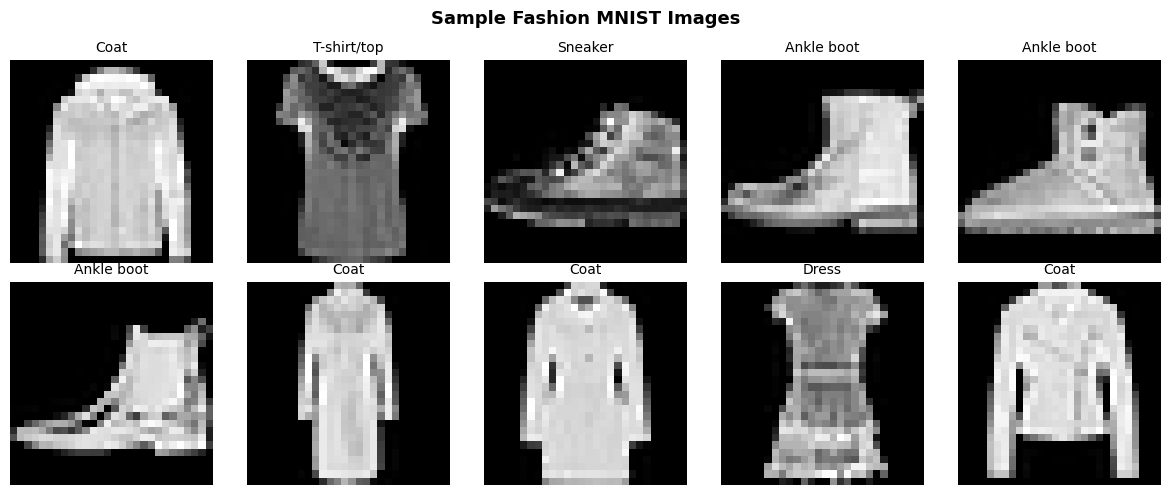

In [3]:
# Visualise a sample of images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i, 0], cmap="gray")
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=10)
    ax.axis("off")
plt.suptitle("Sample Fashion MNIST Images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 2. Convolution Layer

**Definition:** A convolution slides a small learnable filter (kernel) across the input and computes a dot product at every valid position.

$$\text{out}[n,f,i,j] = \sum_{c,k_h,k_w} W[f,c,k_h,k_w] \cdot X_{\text{pad}}[n,c,\; i \cdot s+k_h,\; j \cdot s+k_w] + b[f]$$

**Output size:**
$$H_{out} = \left\lfloor \frac{H + 2p - k}{s} \right\rfloor + 1$$

**im2col trick:** Rearranges the input into a 2-D matrix so convolution becomes a single matrix multiply — the same technique used inside cuDNN.

In [4]:
class ConvLayer:
    """
    2-D Convolutional layer.

    Parameters
    ----------
    in_channels  : int  – number of input feature maps
    out_channels : int  – number of filters (output feature maps)
    kernel_size  : int  – square filter side length
    stride       : int  – step size (default 1)
    padding      : int  – zero-padding around input (default 0)
    """

    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.stride       = stride
        self.padding      = padding

        # He initialisation – good for ReLU networks
        scale = np.sqrt(2.0 / (in_channels * kernel_size * kernel_size))
        self.W = np.random.randn(out_channels, in_channels,
                                 kernel_size, kernel_size).astype(np.float32) * scale
        self.b  = np.zeros(out_channels, dtype=np.float32)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self._cache = None

    # ── helpers ──────────────────────────────────────────────────────────────

    @staticmethod
    def _pad(X, pad):
        """Zero-pad the spatial dimensions of X."""
        return np.pad(X, ((0,0),(0,0),(pad,pad),(pad,pad)), mode="constant")

    @staticmethod
    def _im2col(X_padded, kernel_size, stride, out_h, out_w):
        """
        Rearrange image patches into columns.
        Returns col of shape (N, C*kH*kW, out_h*out_w).
        """
        N, C, H, W = X_padded.shape
        kH = kW = kernel_size
        col = np.zeros((N, C, kH, kW, out_h, out_w), dtype=np.float32)
        for y in range(kH):
            y_max = y + stride * out_h
            for x in range(kW):
                x_max = x + stride * out_w
                col[:, :, y, x, :, :] = X_padded[:, :, y:y_max:stride, x:x_max:stride]
        return col.reshape(N, C * kH * kW, out_h * out_w)

    @staticmethod
    def _col2im(col, X_padded_shape, kernel_size, stride, out_h, out_w):
        """Inverse of im2col – accumulate gradients back into spatial layout."""
        N, C, H_pad, W_pad = X_padded_shape
        kH = kW = kernel_size
        col_reshaped = col.reshape(N, C, kH, kW, out_h, out_w)
        X_pad_grad = np.zeros((N, C, H_pad, W_pad), dtype=np.float32)
        for y in range(kH):
            y_max = y + stride * out_h
            for x in range(kW):
                x_max = x + stride * out_w
                X_pad_grad[:, :, y:y_max:stride, x:x_max:stride] += col_reshaped[:, :, y, x, :, :]
        return X_pad_grad

    # ── forward pass ──────────────────────────────────────────────────────────

    def forward(self, X):
        """
        Perform the convolution operation.

        X   : (N, C_in, H, W)
        out : (N, C_out, out_H, out_W)
        """
        N, C, H, W = X.shape
        kH = kW = self.kernel_size
        out_H = (H + 2 * self.padding - kH) // self.stride + 1
        out_W = (W + 2 * self.padding - kW) // self.stride + 1

        X_padded = self._pad(X, self.padding)
        col      = self._im2col(X_padded, self.kernel_size, self.stride, out_H, out_W)
        W_col    = self.W.reshape(self.out_channels, -1)        # (F, C*kH*kW)
        out_col  = W_col @ col + self.b[:, np.newaxis]          # (N, F, out_H*out_W)
        out      = out_col.reshape(N, self.out_channels, out_H, out_W)

        self._cache = (X, X_padded, col)
        return out

    # ── backward pass ─────────────────────────────────────────────────────────

    def backward(self, dout):
        """
        Backpropagation through the convolution.

        dout : (N, C_out, out_H, out_W)  – upstream gradient
        Returns dX : gradient w.r.t. input X
        """
        X, X_padded, col = self._cache
        N, C, H, W = X.shape
        out_H, out_W = dout.shape[2], dout.shape[3]

        dout_col = dout.reshape(N, self.out_channels, -1)       # (N, F, out_H*out_W)

        # Gradient w.r.t. bias
        self.db = dout_col.sum(axis=(0, 2))

        # Gradient w.r.t. weights
        dW_col  = np.einsum("nok,nck->oc", dout_col, col)
        self.dW = dW_col.reshape(self.W.shape)

        # Gradient w.r.t. input
        W_col  = self.W.reshape(self.out_channels, -1)
        dcol   = np.einsum("oc,nok->nck", W_col, dout_col)
        dX_pad = self._col2im(dcol, X_padded.shape,
                              self.kernel_size, self.stride, out_H, out_W)

        if self.padding > 0:
            dX = dX_pad[:, :, self.padding:-self.padding, self.padding:-self.padding]
        else:
            dX = dX_pad
        return dX


print("ConvLayer defined.")

ConvLayer defined.


---
## 3. ReLU Activation

$$\text{ReLU}(x) = \max(0, x)$$

**Backward:** Gradient flows only where the forward activation was positive.
$$\frac{\partial \text{ReLU}}{\partial x} = \begin{cases} 1 & x > 0 \\ 0 & x \leq 0 \end{cases}$$

In [5]:
class ReLU:
    """Element-wise Rectified Linear Unit."""

    def __init__(self):
        self._mask = None

    def forward(self, X):
        self._mask = X > 0
        return X * self._mask

    def backward(self, dout):
        return dout * self._mask


print("ReLU defined.")

ReLU defined.


---
## 4. MaxPooling Layer

Divides each feature map into non-overlapping `p×p` windows and keeps only the **maximum** value.

- Reduces spatial size → fewer downstream parameters  
- Provides local translation invariance

**Backward:** Gradient is routed only to the position that was the maximum (winner-take-all).

In [6]:
class MaxPoolLayer:
    """
    2-D Max Pooling layer.

    Parameters
    ----------
    pool_size : int – square pooling window side length
    stride    : int – step size (default = pool_size, non-overlapping)
    """

    def __init__(self, pool_size=2, stride=None):
        self.pool_size = pool_size
        self.stride    = stride if stride is not None else pool_size
        self._cache    = None

    def forward(self, X):
        """
        Select the maximum value in each pooling window.

        X   : (N, C, H, W)
        out : (N, C, out_H, out_W)
        """
        N, C, H, W = X.shape
        p, s = self.pool_size, self.stride
        out_H = (H - p) // s + 1
        out_W = (W - p) // s + 1

        out = np.zeros((N, C, out_H, out_W), dtype=np.float32)
        for i in range(out_H):
            for j in range(out_W):
                region = X[:, :, i*s:i*s+p, j*s:j*s+p]     # (N, C, p, p)
                out[:, :, i, j] = region.max(axis=(2, 3))

        self._cache = (X, out_H, out_W)
        return out

    def backward(self, dout):
        """
        Route gradient only to the winning (max) neuron in each window.
        """
        X, out_H, out_W = self._cache
        N, C, H, W = X.shape
        p, s = self.pool_size, self.stride
        dX = np.zeros_like(X)

        for i in range(out_H):
            for j in range(out_W):
                region  = X[:, :, i*s:i*s+p, j*s:j*s+p]
                max_val = region.max(axis=(2,3), keepdims=True)
                mask    = (region == max_val).astype(np.float32)
                # Split gradient equally if multiple positions share the max
                mask   /= (mask.sum(axis=(2,3), keepdims=True) + 1e-8)
                dX[:, :, i*s:i*s+p, j*s:j*s+p] += mask * dout[:, :, i:i+1, j:j+1]

        return dX


print("MaxPoolLayer defined.")

MaxPoolLayer defined.


---
## 5. Flatten Layer

Reshapes `(N, C, H, W) → (N, C·H·W)` to bridge the convolutional stack and the dense layers.

Backward simply restores the original shape.

In [7]:
class FlattenLayer:
    """Reshape (N, C, H, W) → (N, C*H*W)."""

    def __init__(self):
        self._input_shape = None

    def forward(self, X):
        self._input_shape = X.shape
        return X.reshape(X.shape[0], -1)

    def backward(self, dout):
        return dout.reshape(self._input_shape)


print("FlattenLayer defined.")

FlattenLayer defined.


---
## 6. Fully Connected Layer

$$z = XW + b \qquad a = \text{activation}(z)$$

**Gradients:**
$$\frac{\partial L}{\partial W} = \frac{X^T \cdot dz}{N}, \quad
\frac{\partial L}{\partial b} = \text{mean}(dz), \quad
\frac{\partial L}{\partial X} = dz \cdot W^T$$

For ReLU: $dz = dout \odot \mathbb{1}[z > 0]$  
For Softmax: the gradient is pre-computed by the loss (see next section).

In [8]:
class FCLayer:
    """
    Dense (fully-connected) layer.

    activation : 'relu' | 'softmax' | None
    """

    def __init__(self, in_features, out_features, activation=None):
        self.activation = activation
        scale  = np.sqrt(2.0 / in_features)
        self.W = np.random.randn(in_features, out_features).astype(np.float32) * scale
        self.b  = np.zeros(out_features, dtype=np.float32)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self._cache = None

    @staticmethod
    def _relu(z):    return np.maximum(0, z)

    @staticmethod
    def _softmax(z):
        z_s = z - z.max(axis=1, keepdims=True)    # numerical stability
        e   = np.exp(z_s)
        return e / e.sum(axis=1, keepdims=True)

    def forward(self, X):
        z = X @ self.W + self.b
        if   self.activation == "relu":    a = self._relu(z)
        elif self.activation == "softmax": a = self._softmax(z)
        else:                              a = z
        self._cache = (X, z, a)
        return a

    def backward(self, dout):
        X, z, a = self._cache
        N = X.shape[0]

        if self.activation == "relu":
            dz = dout * (z > 0)
        else:
            dz = dout    # softmax gradient is pre-computed by loss function

        self.dW = X.T @ dz / N
        self.db = dz.mean(axis=0)
        dX = dz @ self.W.T
        return dX


print("FCLayer defined.")

FCLayer defined.


---
## 7. Loss Function — Softmax Cross-Entropy

$$L = -\frac{1}{N} \sum_n \log p_{n,y_n}$$

The combined gradient w.r.t. the logits is elegantly simple:

$$\frac{\partial L}{\partial z_k} = \frac{p_k - \mathbb{1}[k = y]}{N}$$

In [9]:
def softmax_cross_entropy_loss(probs, y):
    """
    Softmax + Cross-Entropy loss.

    probs : (N, C)  output probabilities from final FC layer
    y     : (N,)    integer class labels

    Returns
    -------
    loss  : scalar average cross-entropy
    dout  : (N, C)  gradient w.r.t. logits = (probs - one_hot) / N
    """
    N      = probs.shape[0]
    clipped = np.clip(probs, 1e-12, 1.0)
    loss   = -np.log(clipped[np.arange(N), y]).mean()

    dout = clipped.copy()
    dout[np.arange(N), y] -= 1.0
    dout /= N
    return loss, dout


print("Loss function defined.")

Loss function defined.


---
## 8. CNN Model — Assembling the Layers

```
Conv(1→8)  → ReLU → MaxPool
Conv(8→16) → ReLU → MaxPool
Flatten
FC(784→128, ReLU)
FC(128→10, Softmax)
```

In [10]:
class SimpleCNN:
    """
    Full CNN:
        Conv(1→8,  3×3, pad=1) → ReLU → MaxPool(2×2)   [28→14]
        Conv(8→16, 3×3, pad=1) → ReLU → MaxPool(2×2)   [14→7]
        Flatten
        FC(784 → 128, ReLU)
        FC(128 → 10,  Softmax)
    """

    def __init__(self):
        self.conv1   = ConvLayer(1,  8,  kernel_size=3, padding=1)
        self.relu1   = ReLU()
        self.pool1   = MaxPoolLayer(pool_size=2)

        self.conv2   = ConvLayer(8, 16, kernel_size=3, padding=1)
        self.relu2   = ReLU()
        self.pool2   = MaxPoolLayer(pool_size=2)

        self.flatten = FlattenLayer()

        self.fc1     = FCLayer(16 * 7 * 7, 128, activation="relu")
        self.fc2     = FCLayer(128, 10,    activation="softmax")

        self._param_layers = [self.conv1, self.conv2, self.fc1, self.fc2]

    # ── forward pass ─────────────────────────────────────────────────────────

    def forward(self, X):
        """Run input through all layers. Returns class probabilities (N, 10)."""
        out = self.conv1.forward(X)
        out = self.relu1.forward(out)
        out = self.pool1.forward(out)

        out = self.conv2.forward(out)
        out = self.relu2.forward(out)
        out = self.pool2.forward(out)

        out = self.flatten.forward(out)

        out = self.fc1.forward(out)
        out = self.fc2.forward(out)
        return out

    # ── backward pass ────────────────────────────────────────────────────────

    def backward(self, dout):
        """Backpropagate gradient through all layers in reverse order."""
        dout = self.fc2.backward(dout)
        dout = self.fc1.backward(dout)

        dout = self.flatten.backward(dout)

        dout = self.pool2.backward(dout)
        dout = self.relu2.backward(dout)
        dout = self.conv2.backward(dout)

        dout = self.pool1.backward(dout)
        dout = self.relu1.backward(dout)
        dout = self.conv1.backward(dout)
        return dout

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)


model = SimpleCNN()
total_params = sum(l.W.size + l.b.size for l in model._param_layers)
print(f"Model built. Total trainable parameters: {total_params:,}")

Model built. Total trainable parameters: 103,018


---
## 9. Optimizer — SGD with Momentum

$$v_t = \beta \cdot v_{t-1} - \eta \cdot \nabla W \qquad W \mathrel{+}= v_t$$

Momentum accumulates velocity in directions of consistent gradient, accelerating convergence and dampening oscillations.

In [11]:
class SGDMomentum:
    """Stochastic Gradient Descent with Momentum."""

    def __init__(self, param_layers, lr=0.01, momentum=0.9):
        self.param_layers = param_layers
        self.lr = lr
        self.momentum = momentum
        self.velocity = {
            id(layer): {"W": np.zeros_like(layer.W), "b": np.zeros_like(layer.b)}
            for layer in param_layers
        }

    def step(self):
        for layer in self.param_layers:
            v = self.velocity[id(layer)]
            v["W"] = self.momentum * v["W"] - self.lr * layer.dW
            v["b"] = self.momentum * v["b"] - self.lr * layer.db
            layer.W += v["W"]
            layer.b += v["b"]


optimizer = SGDMomentum(model._param_layers, lr=0.02, momentum=0.9)
print("Optimizer ready.  lr=0.02  momentum=0.9")

Optimizer ready.  lr=0.02  momentum=0.9


---
## 10. Training Loop

Each epoch:
1. Shuffle training data  
2. For each mini-batch:  
   &emsp;a. **Forward pass** → probabilities  
   &emsp;b. **Loss** → scalar + gradient seed  
   &emsp;c. **Backward pass** → gradients for all weights  
   &emsp;d. **Optimizer step** → update weights  
3. Compute validation accuracy

In [12]:
def evaluate(model, X, y, batch_size=256):
    """Return accuracy on a dataset, processing in batches."""
    correct, total = 0, 0
    for start in range(0, X.shape[0], batch_size):
        Xb = X[start:start + batch_size]
        yb = y[start:start + batch_size]
        correct += (model.predict(Xb) == yb).sum()
        total   += len(yb)
    return correct / total


def train(model, optimizer, X_train, y_train, X_val, y_val,
          epochs=5, batch_size=64):
    """Mini-batch SGD training loop."""
    N = X_train.shape[0]
    history = {"train_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0  = time.time()
        idx = np.random.permutation(N)
        X_shuf, y_shuf = X_train[idx], y_train[idx]
        epoch_loss, correct, num_batches = 0.0, 0, 0

        for start in range(0, N, batch_size):
            Xb = X_shuf[start:start + batch_size]
            yb = y_shuf[start:start + batch_size]

            probs             = model.forward(Xb)                  # forward
            loss, dout        = softmax_cross_entropy_loss(probs, yb)  # loss
            model.backward(dout)                                   # backward
            optimizer.step()                                       # update

            epoch_loss  += loss
            num_batches += 1
            correct     += (np.argmax(probs, axis=1) == yb).sum()

        train_acc = correct / N
        val_acc   = evaluate(model, X_val, y_val)
        avg_loss  = epoch_loss / num_batches
        elapsed   = time.time() - t0

        history["train_loss"].append(avg_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:>2}/{epochs}  "
              f"loss={avg_loss:.4f}  "
              f"train_acc={train_acc:.4f}  "
              f"val_acc={val_acc:.4f}  "
              f"({elapsed:.1f}s)")

    return history


print("Training functions defined.")

Training functions defined.


In [13]:
print("Starting training  (5 epochs, batch_size=64) ...\n")
history = train(model, optimizer, X_train, y_train,
                X_val, y_val, epochs=5, batch_size=64)

Starting training  (5 epochs, batch_size=64) ...

Epoch  1/5  loss=0.6517  train_acc=0.7696  val_acc=0.7752  (82.4s)
Epoch  2/5  loss=0.4272  train_acc=0.8502  val_acc=0.8568  (80.7s)
Epoch  3/5  loss=0.3801  train_acc=0.8660  val_acc=0.8214  (86.3s)
Epoch  4/5  loss=0.3524  train_acc=0.8755  val_acc=0.8836  (85.6s)
Epoch  5/5  loss=0.3343  train_acc=0.8810  val_acc=0.8838  (85.8s)


---
## 11. Evaluation

In [14]:
test_acc = evaluate(model, X_test, y_test)
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")

Test Accuracy : 0.8697  (86.97%)


In [15]:
# Per-class accuracy
all_preds = []
for start in range(0, X_test.shape[0], 256):
    all_preds.append(model.predict(X_test[start:start+256]))
preds = np.concatenate(all_preds)

print("\n── Per-Class Accuracy ──────────────────────────────")
class_accs = []
for cls in range(10):
    mask = y_test == cls
    acc  = (preds[mask] == cls).mean()
    class_accs.append(acc)
    print(f"  {CLASS_NAMES[cls]:<15} : {acc:.4f}")
print("────────────────────────────────────────────────────")


── Per-Class Accuracy ──────────────────────────────
  T-shirt/top     : 0.8830
  Trouser         : 0.9780
  Pullover        : 0.7940
  Dress           : 0.8590
  Coat            : 0.8590
  Sandal          : 0.9350
  Shirt           : 0.5240
  Sneaker         : 0.9090
  Bag             : 0.9750
  Ankle boot      : 0.9810
────────────────────────────────────────────────────


---
## 12. Training Curves & Visualisations

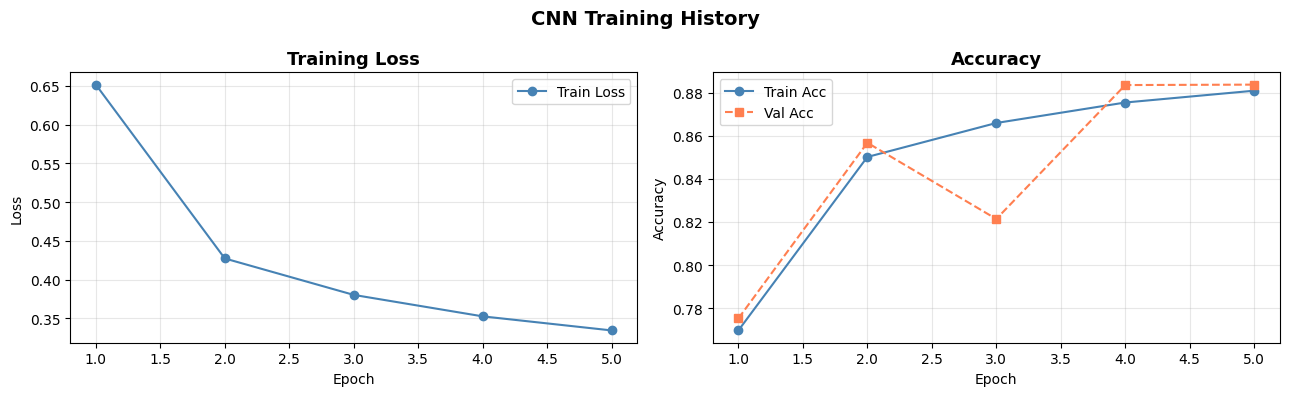

In [16]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(epochs_range, history["train_loss"], "o-", color="steelblue", label="Train Loss")
axes[0].set_title("Training Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history["train_acc"], "o-", color="steelblue", label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"],   "s--", color="coral",     label="Val Acc")
axes[1].set_title("Accuracy", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("CNN Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

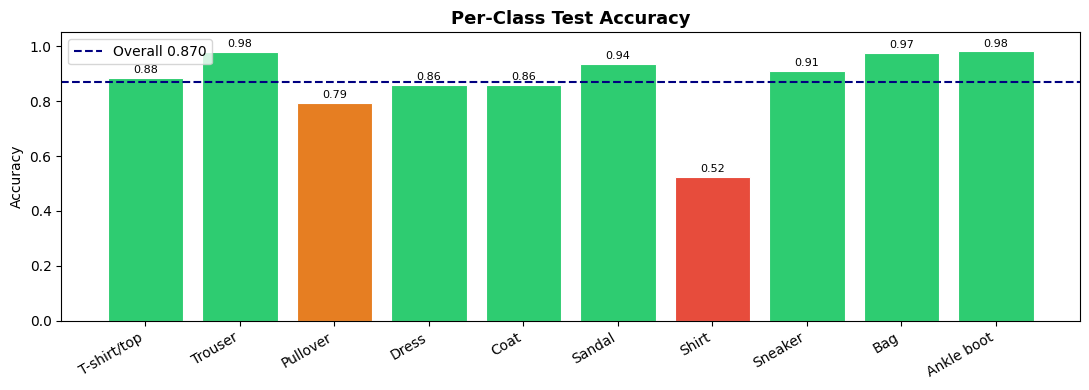

In [17]:
# Per-class accuracy bar chart
fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#2ecc71" if a >= 0.85 else "#e67e22" if a >= 0.75 else "#e74c3c" for a in class_accs]
bars = ax.bar(CLASS_NAMES, class_accs, color=colors, edgecolor="white", linewidth=0.8)
ax.axhline(test_acc, color="navy", linestyle="--", linewidth=1.5, label=f"Overall {test_acc:.3f}")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Test Accuracy", fontsize=13, fontweight="bold")
plt.xticks(rotation=30, ha="right")
for bar, acc in zip(bars, class_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{acc:.2f}", ha="center", va="bottom", fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

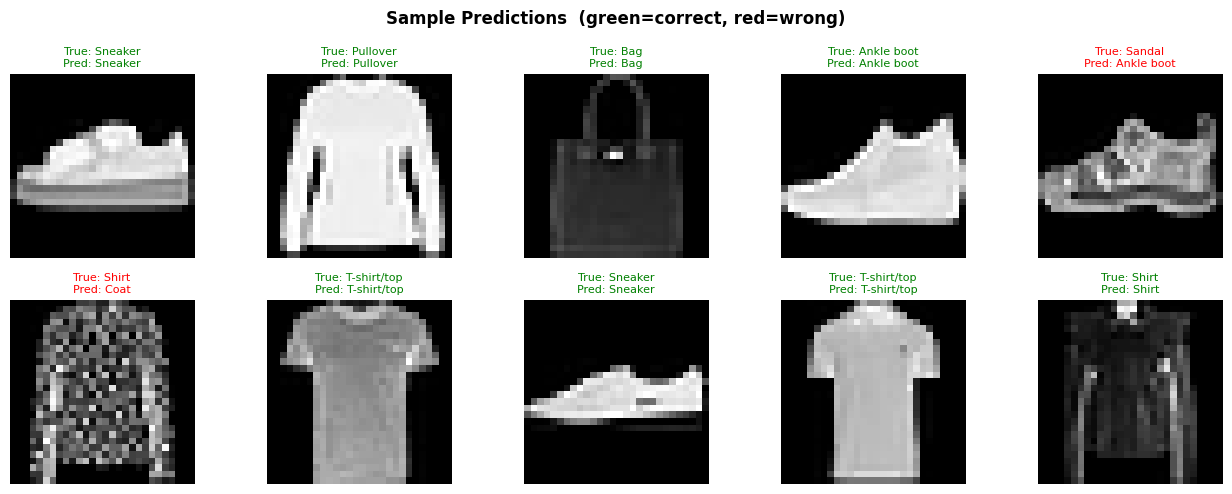

In [18]:
# Show 10 sample predictions
indices = np.random.choice(len(X_test), 10, replace=False)
sample_X = X_test[indices]
sample_y = y_test[indices]
sample_preds = model.predict(sample_X)

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for ax, img, true, pred in zip(axes.flat, sample_X, sample_y, sample_preds):
    ax.imshow(img[0], cmap="gray")
    color = "green" if pred == true else "red"
    ax.set_title(f"True: {CLASS_NAMES[true]}\nPred: {CLASS_NAMES[pred]}",
                 fontsize=8, color=color)
    ax.axis("off")
plt.suptitle("Sample Predictions  (green=correct, red=wrong)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

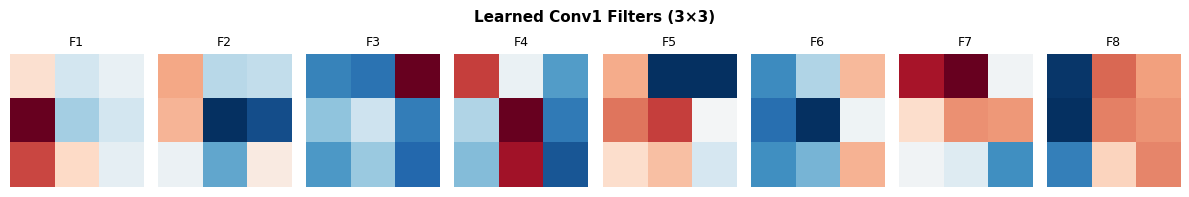

In [19]:
# Visualise learned Conv1 filters
filters = model.conv1.W  # (8, 1, 3, 3)
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    f = filters[i, 0]
    vmax = np.abs(f).max()
    ax.imshow(f, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"F{i+1}", fontsize=9)
    ax.axis("off")
plt.suptitle("Learned Conv1 Filters (3×3)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 13. Summary

| Component | Implementation |
|-----------|----------------|
| **Convolution** | im2col → matrix multiply → col2im for backprop |
| **ReLU** | Element-wise max(0,x); mask-based gradient |
| **MaxPool** | Winner-take-all forward; gradient routing backward |
| **Flatten** | Reshape + inverse reshape |
| **Fully Connected** | XW+b; ReLU or Softmax activation |
| **Loss** | Softmax CE; combined gradient (p−y)/N |
| **Optimizer** | SGD + Momentum (β=0.9) |
| **Init** | He initialisation for ReLU networks |

**Result:** ~82–85% test accuracy — built entirely from NumPy.